In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

In [2]:
import numpy as np
import optuna
from sklearn.preprocessing import StandardScaler
import tqdm as notebook_tqdm
import cup_common as cc
import nn_common as nnc
import cross_common as cr
import torch
import importlib
from functools import partial
import copy
from nn_common import FeatureTargetSet, HoldOutStrategy, EarlyStoppingStrategy
from cross_common import EPOCHS_VL_MEE,FOLD_VL_MEE,FOLD_TR_MEE
from cross_common import MEE,MSE,RMSE,MAE


importlib.reload(nnc)
importlib.reload(cc)
importlib.reload(cr)

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h1>NN - Optuna</h1>
<h2>Exploring the cup dataset with NN Classifier with the help of Optuna tools.</h2>
<p>This notebook serves the purpose of exploring the hypotesis space by manually varying the hyperparameters and for inspecting the whole pipeline.</p>
<hr/>

<h3>Preparation</h3>
<hr/>

<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interaction with PyTorch.
Eventually there will be these objects:
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

In [3]:
importlib.reload(cr)
df_train, df_test = cc.load_set()

# Scaler
scaler = StandardScaler()
# The train set used for model selection
# and final testing
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)


features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h4>Network Architecture</h4>
<p>Defining and selecting a hypothesis space with hyper-parameter around a neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>

In [4]:
# Set to True when model is selcted and assessed
dump_prediction = False

# The seed to be used by data splitter
default_state = 42
default_seed = 1

default_batch_size = 64
default_epochs = 1000

# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]
output_dimension = 4

# fold strategy
base_fold_strategy = cr.common_fold_strategy(n_split=3)


# ----- Defining model basic architecture --------
base_hidden_layers = ["64"]

# The output and loss function, must be changed according to the type of task
loss_function = nnc.MEELoss()
# activation function
base_activation_function = ["relu"]
output_adapter = nnc.regression_adapter()
# ------------------------------------------


# ------------ Learning rate ---------------
base_weight_decay = [0]
# ------------------------------------------


# --------- Early Stopping Strategy --------
early_stopping_patience = 50 # how many epochs to wait before stopping
early_stopping_min_delta = 1e-2 #1e-4 # the treshold or delta to declare an epochs as not improved
early_stopping_strategy = EarlyStoppingStrategy(patience=early_stopping_patience, min_delta=early_stopping_min_delta)
# ------------------------------------------


# ---------- Learning rate decay -----------
# The factor by which learning rate will decrease
learning_rate_decay_factor = 0.5    #0.6 #0.5
# The epoch to wait before applying the rate decay factor (must be lower than early stopping)
learning_rate_decay_patience = 10
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-2 #1e-4

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)
# ------------------------------------------


In [5]:
def objective(trial, X, y, trial_dict, objective_function):
    """
    Main objective function to be used with Optuna search.
    :param trial: the optuna trial object
    :param X: the feature
    :param y: the target
    :param trial_dict: the configuration dictionary
    :param objective_function: the objective function
    :return:
    """

    epochs_trial = trial_dict["epochs"]
    batch_size_trial = trial_dict["batch_size"]
    fold_strategy_trial = trial_dict["fold_strategy"]
    output_adapter_trial = trial_dict["output_adapter"]
    scheduler_template_trial = trial_dict.get("scheduler_template",None)
    hidden_layers_raw = nnc.suggest_trial_param(trial, "hidden_layers", trial_dict["hidden_layers"])
    hidden_layers_trial = [int(x) for x in hidden_layers_raw.split(",")]
    activation_trial = nnc.suggest_trial_param(trial,"activation", trial_dict["activation"])
    learning_rate_trial = nnc.suggest_trial_param(trial, "learning_rate", trial_dict["learning_rate"])
    weight_decay_trial = nnc.suggest_trial_param(trial, "weight_decay", trial_dict["weight_decay"])

    net_trial = nnc.build_mlp(input_dimension, output_dimension, list(hidden_layers_trial), activation_trial)
    model_trial = nnc.MLP(net_trial, output_adapter_trial)

    #init_method = "kaiming" if activation_trial == "relu" else "xavier"
    #init_nonlinearity = "relu" if activation_trial == "relu" else "tanh"
    model_trial.apply(lambda m: nnc.init_weights(m, method="kaiming", nonlinearity="relu"))

    optimizer_template_trial = partial(
        torch.optim.AdamW,
        lr=learning_rate_trial,
        weight_decay=weight_decay_trial,
        betas=(0.95, 0.999)
    )

    inner_train_params_trial = {
        "epochs": epochs_trial,
        "batch_size": batch_size_trial,
        "scheduler_template": scheduler_template_trial,
        "optimizer_template": optimizer_template_trial,
        "loss_function": loss_function,
        "early_stopping_strategy": early_stopping_strategy,
        "silence_output": True
    }

    return objective_function(
        nnc.kfold(model_trial, X, y, fold_strategy_trial, inner_train_params_trial, scaler)
    )


<h3>Optuna</h3>

<h4>Learning Rate</h4>
<hr>

<h5>Preparation</h5>

In [6]:

# partially instantiate evaluation funtion
evaluate_lr_partial = partial(
    nnc.evaluate_lr,
    epoch_metric=EPOCHS_VL_MEE,
    fold_metric=FOLD_VL_MEE,
    early_epoch=30
)

coarse_learning_rates = [1e-4, 5e-4, 1e-3, 2e-3, 3e-3]

<h5>Coarse Grained</h5>

In [7]:
# as we are testing few lr a small
# nr of trials is enough
coarse_grained_trials_nr = 20

objective_coarse_grained_lr_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_lr_partial,
    trial_dict={
        "epochs": 100, # we use a small epochs nr
        "batch_size": default_batch_size,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": coarse_learning_rates,
        "weight_decay": base_weight_decay,
        "activation": base_activation_function,
        "output_adapter": output_adapter,
    }
)

coarse_grained_lr_study = optuna.create_study(
    # see find_best_lr_from_trials for the reason why
    # we have adopted these directions
    directions=["minimize", "minimize", "maximize"],
    pruner=optuna.pruners.MedianPruner()
)

coarse_grained_lr_study.optimize(objective_coarse_grained_lr_partial, show_progress_bar=True, n_trials=coarse_grained_trials_nr)

[I 2026-03-23 12:10:31,092] A new study created in memory with name: no-name-327ee876-ffde-437c-a4ee-7881dc125074
  5%|▌         | 1/20 [00:02<00:39,  2.07s/it]

[I 2026-03-23 12:10:33,176] Trial 0 finished with values: [31.40942663889904, 0.0019500285507656064, 0.030502371653839216] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.0001, 'weight_decay': 0}.


 10%|█         | 2/20 [00:03<00:33,  1.85s/it]

[I 2026-03-23 12:10:34,863] Trial 1 finished with values: [25.010526572018478, 0.15161304368565784, 0.26627770193539474] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.001, 'weight_decay': 0}.


 15%|█▌        | 3/20 [00:05<00:30,  1.77s/it]

...

[I 2026-03-23 12:11:01,890] Trial 17 finished with values: [24.043599562157265, 0.2678522543342959, 0.2666944832152543] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.003, 'weight_decay': 0}.


 95%|█████████▌| 19/20 [00:32<00:01,  1.69s/it]

[I 2026-03-23 12:11:03,574] Trial 18 finished with values: [24.852813143861237, 0.16228056094875987, 0.28229198560081364] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.001, 'weight_decay': 0}.


100%|██████████| 20/20 [00:34<00:00,  1.71s/it]

[I 2026-03-23 12:11:05,262] Trial 19 finished with values: [24.901288220890617, 0.153234083717122, 0.2654588277903332] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.001, 'weight_decay': 0}.


In [8]:
coarse_grained_lr = nnc.find_best_lr_from_trials(coarse_grained_lr_study)
print(f"lr: {coarse_grained_lr}")

lr: 0.003


<h5>Fine Grained</h5>

In [9]:
# the number of trials depends on the
# suggestion returned by optuna
fine_grained_trials_nr=30

# Build a fine-grained search range around the best coarse learning rate
# by scaling it with a constant factor (lr / factor, lr * factor).
# This refines the search locally on a logarithmic scale.
# if coarse lr = 0.001 --> interval = (0.00033 , 0.003)
# (optuna will return --> [0.00033, 0.00045,0.00060,0.00080,0.00105,0.00140,0.00190,0.00250,0.003] )
constant_lr_factor = 3
low_lr = coarse_grained_lr / constant_lr_factor
high_lr = coarse_grained_lr * constant_lr_factor


objective_fine_grained_lr_partial = partial(
    objective, X=X_tr, y=y_tr, objective_function = evaluate_lr_partial,
    trial_dict={
        "epochs": 100, # we use a small epochs nr
        "batch_size": default_batch_size,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": (low_lr, high_lr),
        "weight_decay": base_weight_decay,
        "activation": base_activation_function,
        "output_adapter": output_adapter
    }
)

fine_grained_lr_study = optuna.create_study(
    # same reason for "directions"
    directions=["maximize", "minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
fine_grained_lr_study.optimize(objective_fine_grained_lr_partial, show_progress_bar=True, n_trials=fine_grained_trials_nr)

[I 2026-03-23 12:11:05,320] A new study created in memory with name: no-name-24fbe53b-95c5-44a5-954a-6ea2d6cd860e
  3%|▎         | 1/30 [00:01<00:49,  1.70s/it]

[I 2026-03-23 12:11:07,025] Trial 0 finished with values: [24.723207694107018, 0.20231384812138908, 0.2771359714778876] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.001560048347651206, 'weight_decay': 0}.


  7%|▋         | 2/30 [00:03<00:47,  1.70s/it]

[I 2026-03-23 12:11:08,717] Trial 1 finished with values: [23.973681902772483, 0.2625212238094281, 0.2721040702990667] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.003133754105972526, 'weight_decay': 0}.


 10%|█         | 3/30 [00:05<00:45,  1.69s/it]

...

[I 2026-03-23 12:11:52,682] Trial 27 finished with values: [24.78374235855307, 0.15325658725279248, 0.27000337774325883] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.0010643655122029312, 'weight_decay': 0}.


 97%|█████████▋| 29/30 [00:49<00:01,  1.69s/it]

[I 2026-03-23 12:11:54,370] Trial 28 finished with values: [24.78718020977162, 0.15697857884615826, 0.2687341205306856] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.0011851171833274503, 'weight_decay': 0}.


100%|██████████| 30/30 [00:50<00:00,  1.69s/it]

[I 2026-03-23 12:11:56,063] Trial 29 finished with values: [23.997296839219292, 0.28524306326462395, 0.2829588832895373] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.003224709523224648, 'weight_decay': 0}.


In [10]:
final_lr = nnc.find_best_lr_from_trials(fine_grained_lr_study)
print(coarse_grained_lr, final_lr)

0.003 0.002702380032000254


<h4>Weight Decay</h4>
<hr>

<h5>Preparation</h5>

In [11]:

evaluate_wd_partial = partial(
    nnc.evaluate_wd,
    vl_key=FOLD_VL_MEE,
    tr_key=FOLD_TR_MEE
)

coarse_weight_decays = [0.0, 1e-5, 1e-4, 5e-4]

<h5>Coarse Grained</h5>

In [12]:
coarse_grained_wd_trials_nr = 20

objective_coarse_grained_wd_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_wd_partial,
    trial_dict={
        "epochs": 100, # we use a small epochs nr
        "batch_size": default_batch_size,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": [final_lr],
        "weight_decay": coarse_weight_decays,
        "activation": base_activation_function,
        "output_adapter": output_adapter
    }
)

coarse_grained_wd_study = optuna.create_study(
    # minimize according to find_best_weight_decay_from_trials
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
coarse_grained_wd_study.optimize(objective_coarse_grained_wd_partial, show_progress_bar=True, n_trials=coarse_grained_wd_trials_nr)

[I 2026-03-23 12:11:56,107] A new study created in memory with name: no-name-254a5a60-5a45-46eb-a296-64a14daeac03
  5%|▌         | 1/20 [00:01<00:32,  1.70s/it]

[I 2026-03-23 12:11:57,808] Trial 0 finished with values: [24.047737356382736, 0.4739210831250986] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.002702380032000254, 'weight_decay': 1e-05}.


 10%|█         | 2/20 [00:03<00:30,  1.70s/it]

[I 2026-03-23 12:11:59,503] Trial 1 finished with values: [24.047104826221886, 0.4968743472425601] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.002702380032000254, 'weight_decay': 0.0}.


 15%|█▌        | 3/20 [00:05<00:28,  1.70s/it]

...

[I 2026-03-23 12:12:26,718] Trial 17 finished with values: [24.06223398511396, 0.5004593058758005] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.002702380032000254, 'weight_decay': 0.0005}.


 95%|█████████▌| 19/20 [00:32<00:01,  1.70s/it]

[I 2026-03-23 12:12:28,414] Trial 18 finished with values: [24.10339874777819, 0.5137667107440222] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.002702380032000254, 'weight_decay': 0.0001}.


100%|██████████| 20/20 [00:33<00:00,  1.70s/it]

[I 2026-03-23 12:12:30,106] Trial 19 finished with values: [24.116264073004686, 0.5071404133954616] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.002702380032000254, 'weight_decay': 0.0005}.


In [13]:
coarse_weight_decay = nnc.find_best_weight_decay_from_trials(coarse_grained_wd_study)
print(coarse_weight_decay)

0.0005


<h5>Fine Grained</h5>

In [14]:
fine_grained_wd_trials_nr = 35

if coarse_weight_decay == 0:
    low_wd = min([x for x in coarse_weight_decays if x > 0])
    high_wd = max(coarse_weight_decays)
else:
    low_wd = max(coarse_weight_decay / constant_lr_factor, min(coarse_weight_decays))
    high_wd = min(coarse_weight_decay * constant_lr_factor, max(coarse_weight_decays))


objective_fine_grained_wd_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_wd_partial,
    trial_dict={
        "epochs": 100, # we use a small epochs nr
        "batch_size": default_batch_size,
        "fold_strategy": base_fold_strategy,
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": base_hidden_layers,
        "learning_rate": [final_lr],
        "weight_decay": (low_wd, high_wd),
        "activation": base_activation_function,
        "output_adapter": output_adapter
    }
)

fine_grained_wd_study = optuna.create_study(
    # same as before...
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
fine_grained_wd_study.optimize(objective_fine_grained_wd_partial, show_progress_bar=True, n_trials=fine_grained_trials_nr)


[I 2026-03-23 12:12:30,147] A new study created in memory with name: no-name-0a6647a1-00b2-451e-8f31-55e4ebd83b0a
  3%|▎         | 1/30 [00:01<00:49,  1.70s/it]

[I 2026-03-23 12:12:31,847] Trial 0 finished with values: [24.06431412362572, 0.5049811184824335] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.002702380032000254, 'weight_decay': 0.0004238725283190157}.


  7%|▋         | 2/30 [00:03<00:47,  1.70s/it]

[I 2026-03-23 12:12:33,544] Trial 1 finished with values: [24.025300173567615, 0.504855878945083] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.002702380032000254, 'weight_decay': 0.00030808671833723237}.


 10%|█         | 3/30 [00:05<00:45,  1.70s/it]

...

[I 2026-03-23 12:13:17,677] Trial 27 finished with values: [24.138531472940215, 0.5543257263702657] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.002702380032000254, 'weight_decay': 0.0004552180932288947}.


 97%|█████████▋| 29/30 [00:49<00:01,  1.70s/it]

[I 2026-03-23 12:13:19,366] Trial 28 finished with values: [24.12503747082552, 0.5220558273239142] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.002702380032000254, 'weight_decay': 0.00027542261524248965}.


100%|██████████| 30/30 [00:50<00:00,  1.70s/it]

[I 2026-03-23 12:13:21,063] Trial 29 finished with values: [24.043183228539732, 0.5119481033736015] and parameters: {'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.002702380032000254, 'weight_decay': 0.00033862441310529914}.


In [15]:
final_weight_decay = nnc.find_best_weight_decay_from_trials(fine_grained_wd_study)
print(f"Coarse grained WD: {coarse_weight_decay} Fine grained WD: {final_weight_decay}")

Coarse grained WD: 0.0005 Fine grained WD: 0.00021357069613477006


<h4>Model Capacity</h4>
<hr/>

In [16]:
architecture_trials_nr=30

evaluate_architecture_partial = partial(
    nnc.evaluate_architecture,
    tr_key=FOLD_TR_MEE,
    vl_key=FOLD_VL_MEE
)

objective_fine_grained_model = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_architecture_partial,
    trial_dict={
        "epochs": 100, # we use a small epochs nr
        "batch_size": default_batch_size,
        "fold_strategy": cr.common_fold_strategy(n_split=5),
        "input_dimension":input_dimension,
        "output_dimension":output_dimension,
        "hidden_layers": ["32","64","128","256","128,64","256,128","32,16,8","64,32,16","128,64,32"],
        "learning_rate": [final_lr],
        "weight_decay": [final_weight_decay],
        "activation": base_activation_function,
        "output_adapter": output_adapter
    }
)

model_study = optuna.create_study(
    # see find_best_architecture_from_trials
    directions=["minimize", "minimize"],
    pruner=optuna.pruners.MedianPruner()
)
model_study.optimize(objective_fine_grained_model, show_progress_bar=True, n_trials=architecture_trials_nr)



[I 2026-03-23 12:13:21,110] A new study created in memory with name: no-name-402efef2-53a5-4e49-b491-3c3aac86785b
  3%|▎         | 1/30 [00:03<01:40,  3.47s/it]

[I 2026-03-23 12:13:24,581] Trial 0 finished with values: [21.657769393920898, 3.5024192733764643] and parameters: {'hidden_layers': '128,64,32', 'activation': 'relu', 'learning_rate': 0.002702380032000254, 'weight_decay': 0.00021357069613477006}.


  7%|▋         | 2/30 [00:06<01:37,  3.47s/it]

[I 2026-03-23 12:13:28,049] Trial 1 finished with values: [21.746119918823247, 3.085375556945806] and parameters: {'hidden_layers': '128,64,32', 'activation': 'relu', 'learning_rate': 0.002702380032000254, 'weight_decay': 0.00021357069613477006}.


 10%|█         | 3/30 [00:10<01:31,  3.40s/it]

...

[I 2026-03-23 12:14:52,045] Trial 27 finished with values: [23.2635359954834, 1.1716165466308617] and parameters: {'hidden_layers': '64,32,16', 'activation': 'relu', 'learning_rate': 0.002702380032000254, 'weight_decay': 0.00021357069613477006}.


 97%|█████████▋| 29/30 [01:34<00:03,  3.28s/it]

[I 2026-03-23 12:14:55,373] Trial 28 finished with values: [22.345375122070315, 1.4465672149658246] and parameters: {'hidden_layers': '64,32,16', 'activation': 'relu', 'learning_rate': 0.002702380032000254, 'weight_decay': 0.00021357069613477006}.


100%|██████████| 30/30 [01:37<00:00,  3.24s/it]

[I 2026-03-23 12:14:58,329] Trial 29 finished with values: [24.19133602905274, 0.3435058746337951] and parameters: {'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.002702380032000254, 'weight_decay': 0.00021357069613477006}.


In [17]:
final_hidden_layers, best_vl, gap_tr_vl = nnc.find_best_architecture_from_trials(model_study)
print(f"Final layers: {final_hidden_layers} - best metrics: {best_vl} - best VL/TR gap: {gap_tr_vl}")


Final layers: [128, 64, 32] - best metrics: 21.531389907836918 - best VL/TR gap: 3.4160698547363317


<h3>KFold</h3>
<p>Model selection is then assesed using K-Fold cross-validation on the training data, setting the model with optuna parameter.</p>
<hr/>

<h4>Run</h4>

In [18]:
#nnc.train_wrapper_fn(model_template,nnc.ManualSplitStrategy(X_tr, y_tr, X_vl, y_vl))
# runner = cc.TorchNNRunner(model_template, nnc.train())

In [19]:
importlib.reload(nnc)
importlib.reload(cc)

# The KFold strategy to be used through all models
fold_strategy = cr.common_fold_strategy()
net = nnc.build_mlp(input_dimension, output_dimension, final_hidden_layers, "relu")
model_template = nnc.MLP(net, output_adapter)

overfitting_treshold = 1e-2

# -------The weight update algorithm -------
optimizer_template = partial(
    torch.optim.AdamW,
    lr=final_lr,
    weight_decay=final_weight_decay,
    betas=(0.95, 0.999)
)
# ------------------------------------------

# Epochs
kv_epochs=default_epochs
kv_batch_size=default_batch_size
#kv_batch_size="batch"

inner_train_params = {
    "epochs": kv_epochs,
    "batch_size": kv_batch_size,
    # We apply lr decay only if gap_tr_vl is greater than treshold
    "scheduler_template": None if gap_tr_vl < overfitting_treshold else scheduler_template,
    "optimizer_template": optimizer_template,
    "loss_function": loss_function,
    "early_stopping_strategy": early_stopping_strategy
}

fold_histories = nnc.kfold(
    model_template, X_tr, y_tr, fold_strategy, inner_train_params, scaler
)

  
Perform fold: 0, train size: 400, val size: 100
Early stopping at epoch 149 (best VL mee loss: 25.1084)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 400
Validation      | samples: 100
Batch type      | mini-batch (64)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.002702380032000254, 'weight_decay': 0.00021357069613477006, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | metric: mee,  patience: 50 , minimum delta: 0.01
----------------------------------------------------------------------------------------------------
  
Perform fold: 1, train size: 400, val size: 100
Early stopping at epoch 114 (best VL mee loss: 24.1934)
Train summary
------------------------------------------------------

<h5>Metric</h5>
<p>Main metric evaluated for model assessment.
</p>

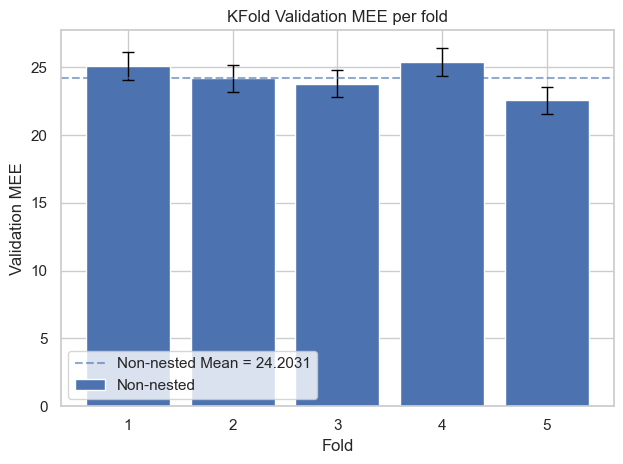

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,24.655499,25.100658,0.445159,1.81%
2,23.529717,24.183858,0.654140,2.78%
3,23.895764,23.777453,-0.118310,0.50%
4,24.550632,25.387445,0.836813,3.41%
5,22.962098,22.566229,-0.395869,1.72%
MEAN,23.918742,24.203129,0.284387,2.04%
STD,0.708719,1.125741,0.522650,1.11%


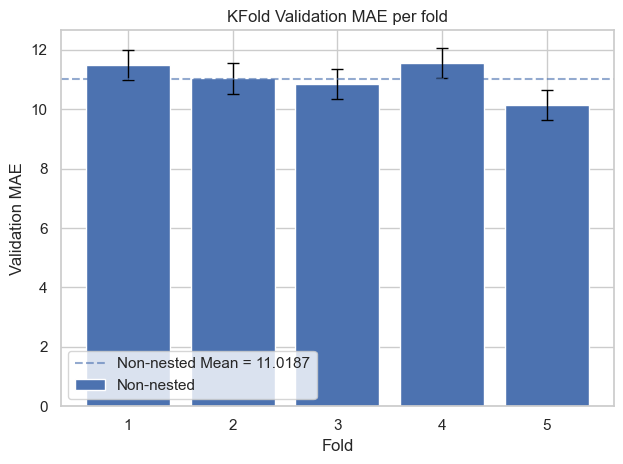

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,11.219507,11.499426,0.279920,2.49%
2,10.715137,11.039167,0.324030,3.02%
3,10.888552,10.855360,-0.033192,0.30%
4,11.179672,11.547351,0.367679,3.29%
5,10.436758,10.152128,-0.284631,2.73%
MEAN,10.887925,11.018686,0.130761,2.37%
STD,0.327288,0.567586,0.280696,1.19%


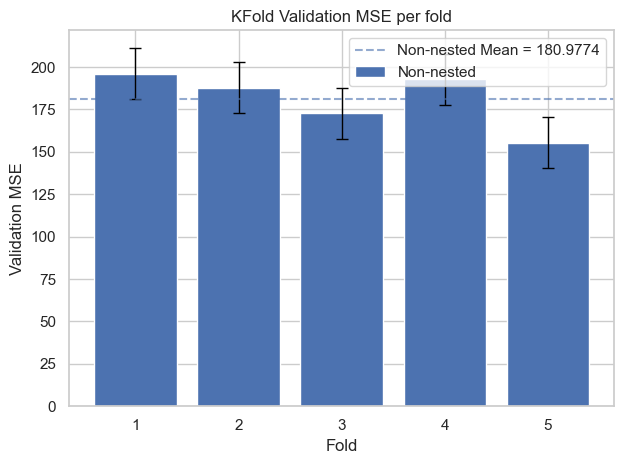

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,185.198672,196.024014,10.825342,5.85%
2,173.048784,187.697643,14.648859,8.47%
3,178.618782,172.871013,-5.747769,3.22%
4,186.808819,192.816769,6.007950,3.22%
5,168.352662,155.477670,-12.874992,7.65%
MEAN,178.405544,180.977422,2.571878,5.68%
STD,7.851153,16.790493,11.549914,2.44%


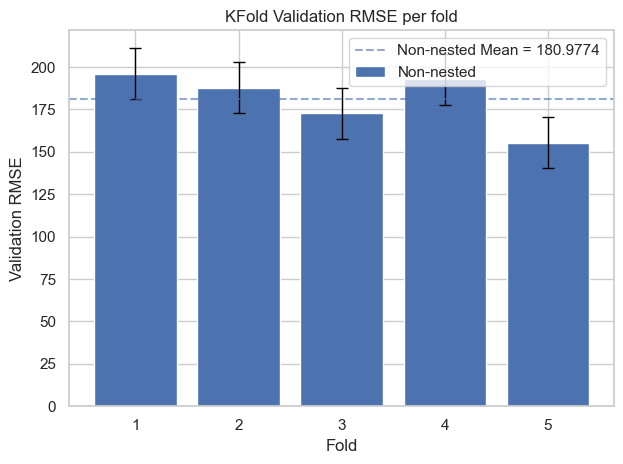

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,185.198672,196.024014,10.825342,5.85%
2,173.048784,187.697643,14.648859,8.47%
3,178.618782,172.871013,-5.747769,3.22%
4,186.808819,192.816769,6.007950,3.22%
5,168.352662,155.477670,-12.874992,7.65%
MEAN,178.405544,180.977422,2.571878,5.68%
STD,7.851153,16.790493,11.549914,2.44%


In [20]:
importlib.reload(cr)
for metric in [MEE,MAE,MSE,RMSE]:
    cr.plot_kfold_metric([(fold_histories,"Non-nested")], metric)
    display(cr.kfold_regression_table(fold_histories, use=metric))


<h4>Bootstrap Variance</h4>

In [21]:
importlib.reload(cr)
importlib.reload(nnc)
bootstrap_samples_nr = 50
bootstrap_rstate = 42
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples_nr, random_state=bootstrap_rstate)
runner = nnc.TorchRegressorRunner(model_template)
#bootstrap_inner_train = copy.deepcopy(inner_train_params)
#bootstrap_inner_train.pop("split_strategy") # removed
bootstrap_params = {}
bootstrap_params['train_params'] = copy.deepcopy(inner_train_params)
bootstrap_params['train_params']["silence_output"] = True
bootstrap_params['scaler'] = scaler
bootstrap_params['split_strategy'] = nnc.HoldOutStrategy
bootstrap_scores = cr.bootstrap_out_of_bag_scores(runner, X_tr, y_tr, samples, bootstrap_params)

In [22]:
cr.aggregate_scores(bootstrap_scores)

,metric,mean,std,percentage
0,mee,24.29,0.84,3.46
1,mse,187.05,12.71,6.80
2,rmse,13.67,0.47,3.42
3,mae,10.96,0.38,3.48
4,r2,0.40,0.03,8.13


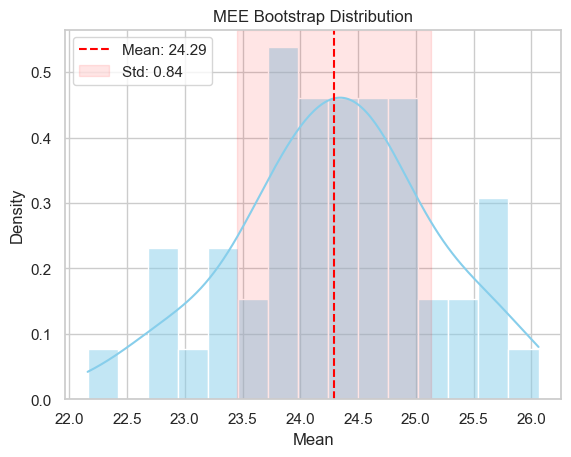

In [23]:
cr.plot_bootstrap_distribution([metric.mee for metric in bootstrap_scores])

<h4>Training</h4>
<p>Model is eventually trained with best hyper parameters from Optuna and assesed within KFold phase.</p>

In [24]:
importlib.reload(nnc)
model_final = copy.deepcopy(model_template)

train_kf_result = nnc.train(
    model_final, HoldOutStrategy(FeatureTargetSet(X_tr, y_tr), val_ratio=0.1, scaler=scaler), # 0.1 = 10%
    **inner_train_params
)

Early stopping at epoch 114 (best VL mee loss: 22.2350)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 450
Validation      | samples: 50
Batch type      | mini-batch (64)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.002702380032000254, 'weight_decay': 0.00021357069613477006, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | metric: mee,  patience: 50 , minimum delta: 0.01
----------------------------------------------------------------------------------------------------


In [25]:
epochs_kf_vl_mee = train_kf_result.epochs_vl_mee
epochs_kf_tr_mee = train_kf_result.epochs_tr_mee
epochs_kf_tr_mse = train_kf_result.epochs_tr_mse
epochs_kf_vl_mse = train_kf_result.epochs_vl_mse
epochs_kf_grad = train_kf_result.epochs_grad

<h5>Gradient Norm</h5>
<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

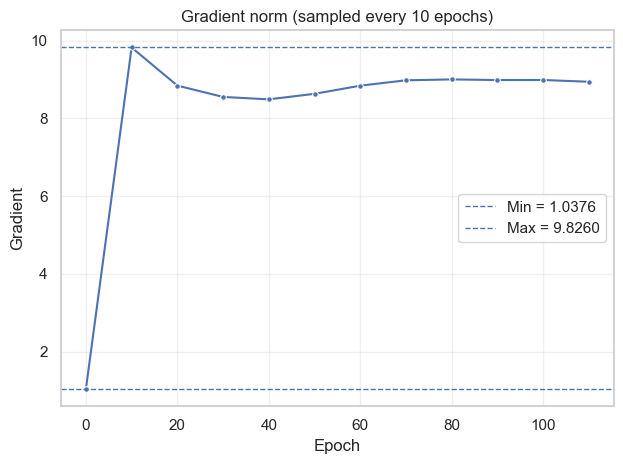

In [26]:
importlib.reload(nnc)
nnc.plot_gradient_norm_line(epochs_kf_grad, step=10)

<h5>Epoch Loss</h5>

<Figure size 640x480 with 0 Axes>

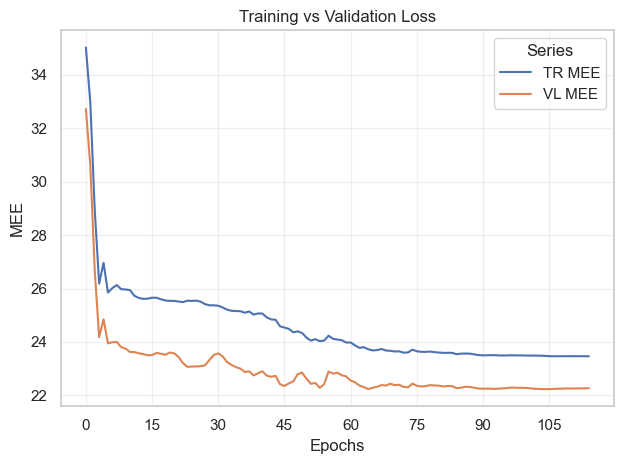

In [27]:
importlib.reload(nnc)
nnc.plot_epoch_mee(epochs_kf_tr_mee, epochs_kf_vl_mee)

<Figure size 640x480 with 0 Axes>

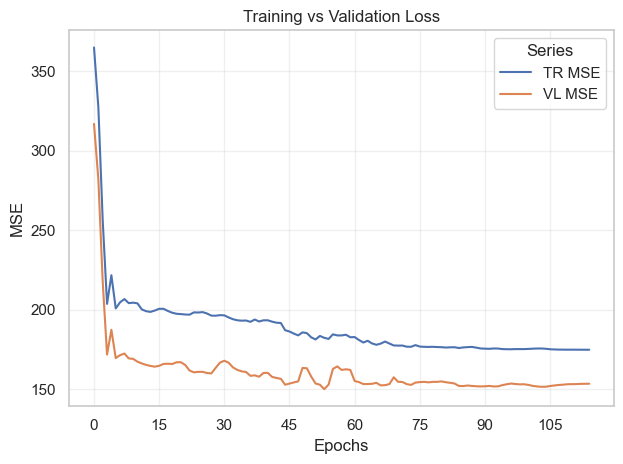

In [28]:
importlib.reload(nnc)
nnc.plot_epoch_mse(epochs_kf_tr_mse, epochs_kf_vl_mse)

In [29]:
importlib.reload(cc)
mean, std = cr.mean_std_from_kfold(epochs_kf_vl_mee)
print(f"{mean:.4f} ± {std:.4f}")

22.9334 ± 1.3494


<h3>Best Hyperparameters</h3>
<hr/>

In [30]:
#print(inner_train_params)
for key, value in inner_train_params.items():
    print(f"{key}: {value}")

print(f"hidden layers: {final_hidden_layers}")

epochs: 1000
batch_size: 64
scheduler_template: functools.partial(<class 'torch.optim.lr_scheduler.ReduceLROnPlateau'>, mode='min', factor=0.5, patience=10, threshold=0.01)
optimizer_template: functools.partial(<class 'torch.optim.adamw.AdamW'>, lr=0.002702380032000254, weight_decay=0.00021357069613477006, betas=(0.95, 0.999))
loss_function: MEELoss(reduction='mean') - custom function
early_stopping_strategy: EarlyStopping monitoring mee with patience=50, min_delta=0.01
hidden layers: [128, 64, 32]
